# 0825_kimjaehak_016_stable_feature_selection

Mapping 기반 검사유형별 XGBoost에서 **시간적으로 안정적인 저기여 피처만 보수적으로 제거**할 수 있는지 검증합니다.

`0824_dongjin_020_dim_reduction`은 SHAP·RuleFit 상위 21개 피처만 남기는 공격적인 축소에서 성능이 크게 하락했습니다. 이번 실험은 전역 Top-K를 강제하지 않고 다음 절차를 사용합니다.

1. 기존 Train 내부의 expanding time fold에서 permutation importance를 계산합니다.
2. 검사유형별로 전체·상위 75%·상위 50%·안정적 양수 중요도·meta 제외 후보를 만듭니다.
3. 기존 Validation에서 성능과 피처 수를 함께 고려해 유형별 후보를 고정합니다.
4. 고정 이후 Test를 한 번 평가합니다.

Test를 본 뒤 중요도 기준, 후보 비율 또는 허용 열화 폭을 변경하지 않습니다.

## 1. 설정과 라이브러리

비용과 운영 threshold 최적화는 다른 실험의 범위이므로 수행하지 않습니다. 주지표는 검사유형별 PR-AUC이며, threshold 0.5 지표와 pooled PR-AUC는 보조적으로만 기록합니다.

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0825_kimjaehak_016_stable_feature_selection"
RANDOM_STATE = 42
DECISION_THRESHOLD = 0.5
PERMUTATION_REPEATS = 3
MIN_SELECTED_FEATURES = 5
ABSOLUTE_PR_AUC_TOLERANCE = 0.01
RELATIVE_PR_AUC_TOLERANCE = 0.05
DATA_PATH = Path("../data/raw/dataset.csv")
MAPPING_PATH = Path("../data/raw/mapping.json")
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"
INNER_WINDOWS = [f"I{number:02d}" for number in range(1, 6)]
INNER_FOLDS = [
    (INNER_WINDOWS[:2], "I03"),
    (INNER_WINDOWS[:3], "I04"),
    (INNER_WINDOWS[:4], "I05"),
]

assert DATA_PATH.exists(), DATA_PATH.resolve()
assert MAPPING_PATH.exists(), MAPPING_PATH.resolve()
print("experiment:", EXPERIMENT_ID)
print("inner folds:", INNER_FOLDS)
print("permutation repeats:", PERMUTATION_REPEATS)

Matplotlib is building the font cache; this may take a moment.


experiment: 0825_kimjaehak_016_stable_feature_selection
inner folds: [(['I01', 'I02'], 'I03'), (['I01', 'I02', 'I03'], 'I04'), (['I01', 'I02', 'I03', 'I04'], 'I05')]
permutation repeats: 3


## 2. 데이터 로딩, 중복 제거와 시간 분할

006·009와 동일하게 `record_id`, `timestamp`를 제외한 입력과 `class`가 모두 같은 행을 중복으로 제거합니다. 전체 데이터의 timestamp 그룹 기준 누적 행 수 약 60/20/20으로 Train/Validation/Test를 나눕니다.

피처 중요도 계산용 `I01~I05`는 Train 안에서만 다시 만든 시간 window입니다. 동일 timestamp 그룹은 어떤 경계에서도 분리하지 않습니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

dedup_columns = [
    column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors="raise", utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind="stable").reset_index(drop=True)

timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def global_boundary_time(fraction):
    position = int(np.searchsorted(cumulative_rows, len(clean_df) * fraction, side="left"))
    return timestamp_group_sizes.index[position]

train_end_time = global_boundary_time(0.60)
validation_end_time = global_boundary_time(0.80)
split_masks = {
    "train": clean_df[TIME_COLUMN] <= train_end_time,
    "validation": (
        (clean_df[TIME_COLUMN] > train_end_time)
        & (clean_df[TIME_COLUMN] <= validation_end_time)
    ),
    "test": clean_df[TIME_COLUMN] > validation_end_time,
}

train_timestamp_sizes = (
    clean_df.loc[split_masks["train"], TIME_COLUMN]
    .value_counts(sort=False)
    .sort_index()
)
train_cumulative_rows = train_timestamp_sizes.cumsum().to_numpy()

def inner_boundary_time(fraction):
    position = int(np.searchsorted(
        train_cumulative_rows,
        int(split_masks["train"].sum()) * fraction,
        side="left",
    ))
    return train_timestamp_sizes.index[position]

inner_end_times = pd.DatetimeIndex(
    [inner_boundary_time(fraction) for fraction in np.arange(0.2, 1.01, 0.2)]
)
train_times = clean_df.loc[split_masks["train"], TIME_COLUMN]
inner_numbers = np.searchsorted(
    inner_end_times.astype("int64").to_numpy(),
    train_times.astype("int64").to_numpy(),
    side="left",
)
clean_df["inner_window"] = pd.Series(pd.NA, index=clean_df.index, dtype="string")
clean_df.loc[split_masks["train"], "inner_window"] = [
    f"I{number + 1:02d}" for number in inner_numbers
]

with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)
inspection_types = sorted(clean_df[TYPE_COLUMN].unique().tolist())
meta_columns = [column for column in clean_df.columns if column.startswith("meta_feat")]
feature_columns_by_type = {
    inspection_type: meta_columns + feature_mapping[str(inspection_type)]
    for inspection_type in inspection_types
}

type_split_dfs = {
    inspection_type: {
        split_name: clean_df.loc[
            split_mask & (clean_df[TYPE_COLUMN] == inspection_type)
        ].copy()
        for split_name, split_mask in split_masks.items()
    }
    for inspection_type in inspection_types
}

split_summary = pd.DataFrame([
    {
        "split": split_name,
        "rows": int(mask.sum()),
        "positives": (
            int(clean_df.loc[mask, TARGET].sum()) if split_name != "test" else np.nan
        ),
        "positive_rate_pct": (
            clean_df.loc[mask, TARGET].mean() * 100 if split_name != "test" else np.nan
        ),
        "start_time": clean_df.loc[mask, TIME_COLUMN].min(),
        "end_time": clean_df.loc[mask, TIME_COLUMN].max(),
    }
    for split_name, mask in split_masks.items()
]).set_index("split")

inner_summary = (
    clean_df.loc[split_masks["train"]]
    .groupby([TYPE_COLUMN, "inner_window"])[TARGET]
    .agg(rows="size", positives="sum")
)

assert len(clean_df) == 391_992
assert sum(split_masks.values()).eq(1).all()
assert clean_df.loc[split_masks["train"]].groupby(TIME_COLUMN)["inner_window"].nunique().max() == 1
assert set(feature_mapping) == {str(value) for value in inspection_types}
display(split_summary)
display(pd.DataFrame({
    "mapped_features": {
        inspection_type: len(feature_columns_by_type[inspection_type])
        for inspection_type in inspection_types
    }
}))
display(inner_summary)

,rows,positives,positive_rate_pct,start_time,end_time
split,,,,,
train,235222,1824.0,0.775438,1970-06-23 03:58:55+00:00,1970-09-28 05:48:26+00:00
validation,78374,363.0,0.463164,1970-09-28 05:49:10+00:00,1970-10-13 13:14:26+00:00
test,78396,NaN,NaN,1970-10-13 13:14:58+00:00,1970-11-02 14:21:28+00:00


,mapped_features
0,48
1,56
2,69
3,69
4,25


rows  positives
inspection_type inner_window                  
0               I01            9753          4
                I02           10104         21
                I03            7664         11
                I04            5667         10
                I05            8773         11
1               I01           10449         63
                I02            6653        176
                I03            7714         46
                I04            3751        190
                I05            5474         80
2               I01           12853          9
                I02           12851        352
                I03           18883         54
                I04           21392        133
                I05            8931         31
3               I01           13640          6
                I02           16455        451
                I03           11721         44
                I04           15863         97
                I05           23113         22
4               I01             352          0
                I02             992          4
                I03            1052          0
                I04             373          6
                I05             749          3

## 3. 공통 모델과 평가 함수

모델 설정은 006 baseline과 동일합니다. Permutation importance는 미래 inner window의 피처 하나를 섞었을 때 PR-AUC가 얼마나 감소하는지 측정합니다. 평가 window에 양성이 없으면 그 Fold는 해당 type의 중요도 계산에서 제외합니다.

In [3]:
def build_model():
    return XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )


def evaluate_probabilities(y_true, probabilities, threshold=DECISION_THRESHOLD):
    y_true = np.asarray(y_true, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    predictions = (probabilities >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": (
            roc_auc_score(y_true, probabilities)
            if len(np.unique(y_true)) > 1 else np.nan
        ),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def fit_model(train_df, feature_columns):
    started_at = time.perf_counter()
    model = build_model()
    model.fit(
        train_df[feature_columns],
        train_df[TARGET].astype("int8"),
        verbose=False,
    )
    return model, time.perf_counter() - started_at


def model_size_bytes(model):
    return len(model.get_booster().save_raw())

## 4. Train 내부 expanding Fold permutation importance

각 Fold는 앞선 inner window로만 학습하고 바로 다음 window에서 중요도를 측정합니다. 같은 피처를 3회 독립적으로 섞고, type·피처별 중요도 중앙값과 양수 중요도 비율을 집계합니다.

Type 4처럼 평가 window에 양성이 없는 경우 PR-AUC 중요도를 정의할 수 없으므로 해당 Fold만 건너뜁니다.

In [4]:
permutation_rows = []
importance_training_rows = []

for inspection_type in inspection_types:
    train_scope_df = type_split_dfs[inspection_type]["train"]
    feature_columns = feature_columns_by_type[inspection_type]

    for fold_number, (training_windows, evaluation_window) in enumerate(INNER_FOLDS, start=1):
        inner_train_df = train_scope_df.loc[
            train_scope_df["inner_window"].isin(training_windows)
        ]
        inner_eval_df = train_scope_df.loc[
            train_scope_df["inner_window"] == evaluation_window
        ]
        eval_positives = int(inner_eval_df[TARGET].sum())
        if eval_positives == 0:
            importance_training_rows.append({
                "inspection_type": inspection_type,
                "fold": fold_number,
                "training_windows": "~".join(training_windows),
                "evaluation_window": evaluation_window,
                "train_rows": len(inner_train_df),
                "evaluation_rows": len(inner_eval_df),
                "evaluation_positives": eval_positives,
                "status": "skipped_no_positive",
                "baseline_pr_auc": np.nan,
                "fit_seconds": np.nan,
            })
            continue

        assert inner_train_df[TIME_COLUMN].max() < inner_eval_df[TIME_COLUMN].min()
        model, fit_seconds = fit_model(inner_train_df, feature_columns)
        X_eval = inner_eval_df[feature_columns]
        y_eval = inner_eval_df[TARGET].astype("int8")
        baseline_probabilities = model.predict_proba(X_eval)[:, 1]
        baseline_pr_auc = average_precision_score(y_eval, baseline_probabilities)
        importance_training_rows.append({
            "inspection_type": inspection_type,
            "fold": fold_number,
            "training_windows": "~".join(training_windows),
            "evaluation_window": evaluation_window,
            "train_rows": len(inner_train_df),
            "evaluation_rows": len(inner_eval_df),
            "evaluation_positives": eval_positives,
            "status": "ok",
            "baseline_pr_auc": baseline_pr_auc,
            "fit_seconds": fit_seconds,
        })

        for feature_number, feature_name in enumerate(feature_columns):
            original_values = X_eval[feature_name].to_numpy(copy=True)
            for repeat in range(PERMUTATION_REPEATS):
                seed = (
                    RANDOM_STATE
                    + inspection_type * 100_000
                    + fold_number * 10_000
                    + feature_number * 10
                    + repeat
                )
                rng = np.random.default_rng(seed)
                X_permuted = X_eval.copy()
                X_permuted[feature_name] = rng.permutation(original_values)
                permuted_probabilities = model.predict_proba(X_permuted)[:, 1]
                permuted_pr_auc = average_precision_score(y_eval, permuted_probabilities)
                permutation_rows.append({
                    "inspection_type": inspection_type,
                    "fold": fold_number,
                    "evaluation_window": evaluation_window,
                    "feature": feature_name,
                    "repeat": repeat,
                    "baseline_pr_auc": baseline_pr_auc,
                    "permuted_pr_auc": permuted_pr_auc,
                    "importance": baseline_pr_auc - permuted_pr_auc,
                })

importance_training_summary = pd.DataFrame(importance_training_rows)
permutation_importance_df = pd.DataFrame(permutation_rows)
display(importance_training_summary)
print("permutation evaluations:", len(permutation_importance_df))

,inspection_type,fold,training_windows,evaluation_window,train_rows,evaluation_rows,evaluation_positives,status,baseline_pr_auc,fit_seconds
0,0,1,I01~I02,I03,19857,7664,11,ok,0.065227,0.250817
1,0,2,I01~I02~I03,I04,27521,5667,10,ok,0.031866,0.210730
2,0,3,I01~I02~I03~I04,I05,33188,8773,11,ok,0.017784,0.215001
3,1,1,I01~I02,I03,17102,7714,46,ok,0.162901,0.243001
4,1,2,I01~I02~I03,I04,24816,3751,190,ok,0.211875,0.211613
5,1,3,I01~I02~I03~I04,I05,28567,5474,80,ok,0.189699,0.219910
6,2,1,I01~I02,I03,25704,18883,54,ok,0.041204,0.224764
7,2,2,I01~I02~I03,I04,44587,21392,133,ok,0.211563,0.243371
8,2,3,I01~I02~I03~I04,I05,65979,8931,31,ok,0.049369,0.267527
9,3,1,I01~I02,I03,30095,11721,44,ok,0.007325,0.227321


permutation evaluations: 2328


,inspection_type,feature,importance_median,importance_mean,importance_std,positive_rate,evaluated_folds,evaluations,stable_score,rank
0,0,inspection_feat12,0.025313,0.029213,0.014922,1.000000,3,9,0.025313,1
1,0,inspection_feat41,0.014148,0.014648,0.012009,1.000000,3,9,0.014148,2
2,0,inspection_feat23,0.013124,0.013901,0.023936,0.888889,3,9,0.011666,3
3,0,inspection_feat24,0.010597,0.005876,0.022620,0.777778,3,9,0.008242,4
4,0,meta_feat4,0.008355,0.006185,0.029713,0.777778,3,9,0.006499,5
5,0,inspection_feat10,0.007519,0.013161,0.020263,0.777778,3,9,0.005848,6
6,0,inspection_feat53,0.003045,0.004401,0.008767,0.666667,3,9,0.002030,7
7,0,inspection_feat42,0.002115,0.002359,0.002391,0.777778,3,9,0.001645,8
8,0,inspection_feat11,0.002112,-0.000986,0.011704,0.777778,3,9,0.001643,9
9,0,meta_feat2,0.002932,0.000400,0.043153,0.555556,3,9,0.001629,10


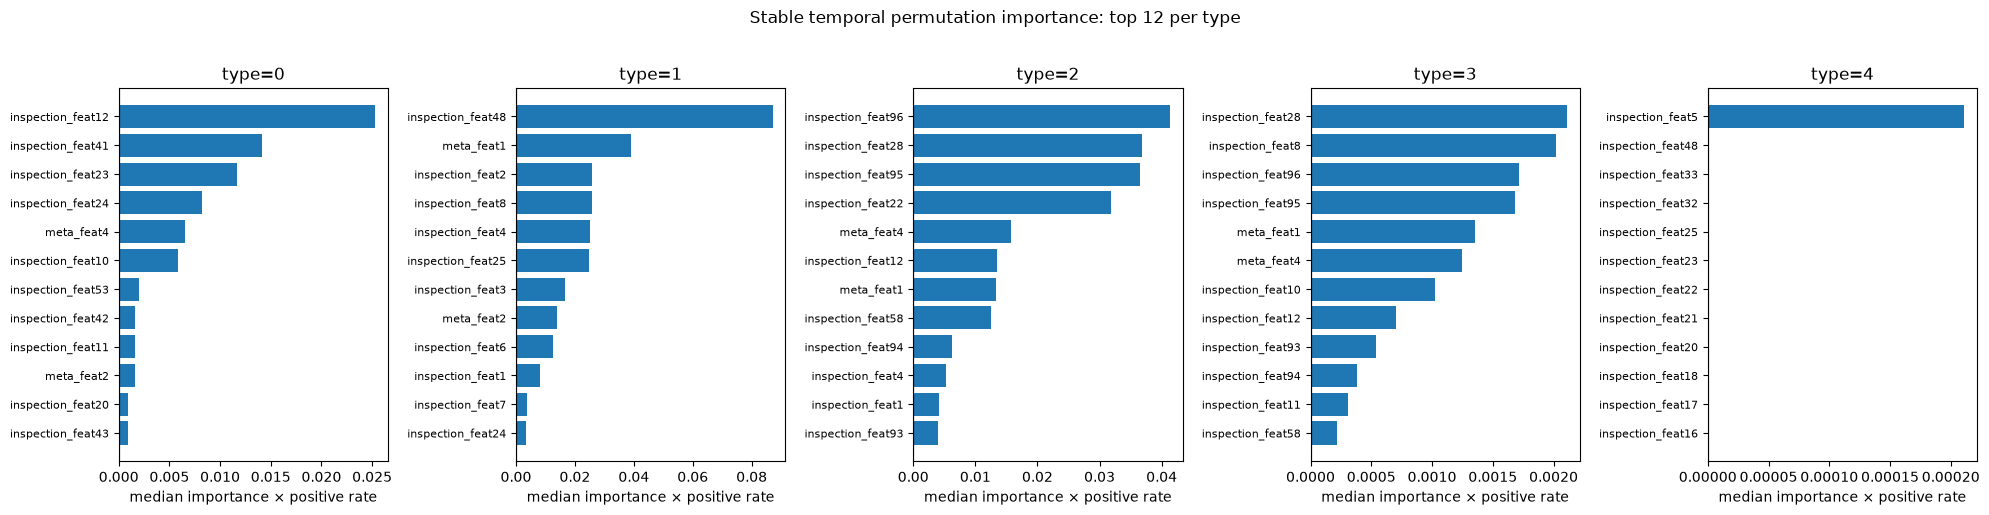

In [5]:
importance_summary = (
    permutation_importance_df
    .groupby(["inspection_type", "feature"], as_index=False)
    .agg(
        importance_median=("importance", "median"),
        importance_mean=("importance", "mean"),
        importance_std=("importance", "std"),
        positive_rate=("importance", lambda values: (values > 0).mean()),
        evaluated_folds=("fold", "nunique"),
        evaluations=("importance", "size"),
    )
)
importance_summary["stable_score"] = (
    importance_summary["importance_median"]
    * importance_summary["positive_rate"]
)
importance_summary = importance_summary.sort_values(
    ["inspection_type", "stable_score", "importance_median", "feature"],
    ascending=[True, False, False, True],
).reset_index(drop=True)
importance_summary["rank"] = (
    importance_summary.groupby("inspection_type").cumcount() + 1
)

display(
    importance_summary.groupby("inspection_type", group_keys=False).head(12)
)

fig, axes = plt.subplots(1, len(inspection_types), figsize=(20, 5), sharex=False)
for ax, inspection_type in zip(axes, inspection_types):
    plot_df = importance_summary.loc[
        importance_summary["inspection_type"] == inspection_type
    ].head(12).sort_values("stable_score")
    ax.barh(plot_df["feature"], plot_df["stable_score"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"type={inspection_type}")
    ax.set_xlabel("median importance × positive rate")
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Stable temporal permutation importance: top 12 per type", y=1.02)
plt.tight_layout()
plt.show()

## 5. 검사유형별 축소 후보 생성

- `all_features`: mapping 기반 전체 피처
- `top_75_pct`: 안정적 중요도 순위 상위 75%
- `top_50_pct`: 안정적 중요도 순위 상위 50%
- `stable_positive`: importance 중앙값이 양수이고 반복의 절반 이상에서 양수인 피처
- `no_meta`: 공통 meta 피처를 제외한 mapping inspection 피처

어떤 후보도 최소 5개보다 적은 피처를 사용하지 않습니다. 동일한 피처 집합이 만들어지면 중복 후보를 제거합니다.

In [6]:
candidate_features_by_type = {}
candidate_rows = []

for inspection_type in inspection_types:
    all_features = feature_columns_by_type[inspection_type]
    ranked = importance_summary.loc[
        importance_summary["inspection_type"] == inspection_type
    ].sort_values("rank")
    ranked_features = ranked["feature"].tolist()
    stable_positive_features = ranked.loc[
        (ranked["importance_median"] > 0)
        & (ranked["positive_rate"] >= 0.50),
        "feature",
    ].tolist()
    if len(stable_positive_features) < MIN_SELECTED_FEATURES:
        stable_positive_features = ranked_features[:MIN_SELECTED_FEATURES]

    raw_candidates = {
        "all_features": all_features,
        "top_75_pct": ranked_features[:max(
            MIN_SELECTED_FEATURES, int(np.ceil(len(all_features) * 0.75))
        )],
        "top_50_pct": ranked_features[:max(
            MIN_SELECTED_FEATURES, int(np.ceil(len(all_features) * 0.50))
        )],
        "stable_positive": stable_positive_features,
        "no_meta": [feature for feature in all_features if feature not in meta_columns],
    }

    candidate_features_by_type[inspection_type] = {}
    seen_signatures = set()
    for candidate_name, candidate_features in raw_candidates.items():
        ordered_features = [
            feature for feature in all_features if feature in set(candidate_features)
        ]
        signature = tuple(ordered_features)
        if signature in seen_signatures:
            continue
        seen_signatures.add(signature)
        candidate_features_by_type[inspection_type][candidate_name] = ordered_features
        candidate_rows.append({
            "inspection_type": inspection_type,
            "candidate": candidate_name,
            "feature_count": len(ordered_features),
            "reduction_count": len(all_features) - len(ordered_features),
            "reduction_pct": 1 - len(ordered_features) / len(all_features),
        })

candidate_summary = pd.DataFrame(candidate_rows)
display(candidate_summary)

,inspection_type,candidate,feature_count,reduction_count,reduction_pct
0,0,all_features,48,0,0.000000
1,0,top_75_pct,36,12,0.250000
2,0,top_50_pct,24,24,0.500000
3,0,stable_positive,14,34,0.708333
4,0,no_meta,44,4,0.083333
5,1,all_features,56,0,0.000000
6,1,top_75_pct,42,14,0.250000
7,1,top_50_pct,28,28,0.500000
8,1,stable_positive,14,42,0.750000
9,1,no_meta,52,4,0.071429


## 6. Validation 기반 보수적 후보 선택

모든 후보를 전체 Train에서 다시 학습하고 Validation PR-AUC로 비교합니다. 최고 후보와 다음 허용폭 이내인 후보 중 피처 수가 가장 작은 것을 선택합니다.

```text
tolerance = min(0.01, 최고 Validation PR-AUC의 5%)
```

낮은 PR-AUC의 희소 type에서 절대 허용폭 0.01이 성능 붕괴까지 허용하지 않도록 상대 허용폭을 함께 적용합니다. Test는 이 단계에서 사용하지 않습니다.

In [7]:
validation_rows = []
validation_models = {}

for inspection_type in inspection_types:
    train_df = type_split_dfs[inspection_type]["train"]
    validation_df = type_split_dfs[inspection_type]["validation"]
    for candidate_name, feature_columns in candidate_features_by_type[inspection_type].items():
        model, fit_seconds = fit_model(train_df, feature_columns)
        validation_probabilities = model.predict_proba(
            validation_df[feature_columns]
        )[:, 1]
        metrics = evaluate_probabilities(
            validation_df[TARGET].astype("int8"),
            validation_probabilities,
        )
        validation_models[(inspection_type, candidate_name)] = model
        validation_rows.append({
            "inspection_type": inspection_type,
            "candidate": candidate_name,
            "feature_count": len(feature_columns),
            "fit_seconds": fit_seconds,
            "model_size_bytes": model_size_bytes(model),
            **metrics,
        })

validation_results = pd.DataFrame(validation_rows)
selection_rows = []

for inspection_type in inspection_types:
    type_results = validation_results.loc[
        validation_results["inspection_type"] == inspection_type
    ].copy()
    best_pr_auc = type_results["pr_auc"].max()
    tolerance = min(
        ABSOLUTE_PR_AUC_TOLERANCE,
        best_pr_auc * RELATIVE_PR_AUC_TOLERANCE,
    )
    eligible = type_results.loc[
        type_results["pr_auc"] >= best_pr_auc - tolerance - 1e-15
    ].sort_values(
        ["feature_count", "pr_auc", "candidate"],
        ascending=[True, False, True],
    )
    selected = eligible.iloc[0]
    baseline = type_results.loc[
        type_results["candidate"] == "all_features"
    ].iloc[0]
    selection_rows.append({
        "inspection_type": inspection_type,
        "selected_candidate": selected["candidate"],
        "baseline_features": int(baseline["feature_count"]),
        "selected_features": int(selected["feature_count"]),
        "reduction_pct": 1 - selected["feature_count"] / baseline["feature_count"],
        "baseline_validation_pr_auc": baseline["pr_auc"],
        "best_validation_pr_auc": best_pr_auc,
        "selection_tolerance": tolerance,
        "selected_validation_pr_auc": selected["pr_auc"],
        "delta_vs_baseline": selected["pr_auc"] - baseline["pr_auc"],
    })

validation_selection = pd.DataFrame(selection_rows).set_index("inspection_type")
display(validation_results.sort_values(["inspection_type", "pr_auc"], ascending=[True, False]))
display(validation_selection)

,inspection_type,candidate,feature_count,fit_seconds,model_size_bytes,pr_auc,roc_auc,accuracy,precision,recall,f1,tn,fp,fn,tp
4,0,no_meta,44,0.219422,140549,0.007489,0.812346,0.999617,0.000000,0.000000,0.000000,23483,1,8,0
1,0,top_75_pct,36,0.213844,144065,0.003966,0.889340,0.999574,0.000000,0.000000,0.000000,23482,2,8,0
0,0,all_features,48,0.227974,145917,0.002405,0.807230,0.999617,0.000000,0.000000,0.000000,23483,1,8,0
2,0,top_50_pct,24,0.205685,152890,0.000852,0.767515,0.999489,0.000000,0.000000,0.000000,23480,4,8,0
3,0,stable_positive,14,0.198629,152472,0.000852,0.767515,0.999489,0.000000,0.000000,0.000000,23480,4,8,0
5,1,all_features,56,0.224693,232681,0.586063,0.937156,0.977987,0.513889,0.619247,0.561670,10115,140,91,148
6,1,top_75_pct,42,0.214735,230472,0.561511,0.932347,0.975986,0.478548,0.606695,0.535055,10097,158,94,145
7,1,top_50_pct,28,0.206529,229884,0.561511,0.932347,0.975986,0.478548,0.606695,0.535055,10097,158,94,145
9,1,no_meta,52,0.214129,242138,0.438728,0.924943,0.955594,0.275248,0.581590,0.373656,9889,366,100,139
8,1,stable_positive,14,0.194805,237048,0.333583,0.907614,0.949018,0.214286,0.464435,0.293263,9848,407,128,111


,selected_candidate,baseline_features,selected_features,reduction_pct,baseline_validation_pr_auc,best_validation_pr_auc,selection_tolerance,selected_validation_pr_auc,delta_vs_baseline
inspection_type,,,,,,,,,
0,no_meta,48,44,0.083333,0.002405,0.007489,0.000374,0.007489,0.005084
1,all_features,56,56,0.000000,0.586063,0.586063,0.010000,0.586063,0.000000
2,no_meta,69,65,0.057971,0.050334,0.428081,0.010000,0.428081,0.377747
3,all_features,69,69,0.000000,0.140335,0.140335,0.007017,0.140335,0.000000
4,top_50_pct,25,13,0.480000,0.054825,0.071144,0.003557,0.071144,0.016320


## 7. 설정 고정 후 최종 Test 평가

Validation에서 유형별 후보가 고정됐는지 확인한 뒤 Test를 처음 평가합니다. 전체 mapping baseline과 선택된 축소 모델을 동일한 threshold 0.5에서 비교합니다.

유형별 raw score scale이 다를 수 있으므로 주 결론은 type별 PR-AUC와 피처 감소율입니다. Pooled PR-AUC는 전체 방향을 보는 보조 지표입니다.

In [8]:
assert set(validation_selection.index) == set(inspection_types)

test_type_rows = []
pooled_probabilities = {
    "baseline": pd.Series(np.nan, index=clean_df.index, dtype="float64"),
    "selected": pd.Series(np.nan, index=clean_df.index, dtype="float64"),
}

for inspection_type in inspection_types:
    test_df = type_split_dfs[inspection_type]["test"]
    selected_candidate = validation_selection.loc[
        inspection_type, "selected_candidate"
    ]
    variants = {
        "baseline": "all_features",
        "selected": selected_candidate,
    }
    for variant, candidate_name in variants.items():
        feature_columns = candidate_features_by_type[inspection_type][candidate_name]
        model = validation_models[(inspection_type, candidate_name)]
        probabilities = model.predict_proba(test_df[feature_columns])[:, 1]
        pooled_probabilities[variant].loc[test_df.index] = probabilities
        metrics = evaluate_probabilities(
            test_df[TARGET].astype("int8"), probabilities
        )
        test_type_rows.append({
            "inspection_type": inspection_type,
            "variant": variant,
            "candidate": candidate_name,
            "feature_count": len(feature_columns),
            **metrics,
        })

test_type_results = pd.DataFrame(test_type_rows)
test_comparison = (
    test_type_results
    .pivot(index="inspection_type", columns="variant")
)
test_delta_rows = []
for inspection_type in inspection_types:
    baseline = test_type_results.loc[
        (test_type_results["inspection_type"] == inspection_type)
        & (test_type_results["variant"] == "baseline")
    ].iloc[0]
    selected = test_type_results.loc[
        (test_type_results["inspection_type"] == inspection_type)
        & (test_type_results["variant"] == "selected")
    ].iloc[0]
    test_delta_rows.append({
        "inspection_type": inspection_type,
        "selected_candidate": selected["candidate"],
        "baseline_features": int(baseline["feature_count"]),
        "selected_features": int(selected["feature_count"]),
        "reduction_pct": 1 - selected["feature_count"] / baseline["feature_count"],
        "baseline_pr_auc": baseline["pr_auc"],
        "selected_pr_auc": selected["pr_auc"],
        "delta_pr_auc": selected["pr_auc"] - baseline["pr_auc"],
        "delta_recall": selected["recall"] - baseline["recall"],
        "delta_tn": int(selected["tn"] - baseline["tn"]),
        "delta_fn": int(selected["fn"] - baseline["fn"]),
    })

test_delta_summary = pd.DataFrame(test_delta_rows).set_index("inspection_type")
display(test_type_results)
display(test_delta_summary)

,inspection_type,variant,candidate,feature_count,pr_auc,roc_auc,accuracy,precision,recall,f1,tn,fp,fn,tp
0,0,baseline,all_features,48,0.068391,0.758519,0.992135,1.000000,0.007519,0.014925,16651,0,132,1
1,0,selected,no_meta,44,0.049924,0.642414,0.992076,0.000000,0.000000,0.000000,16651,0,133,0
2,1,baseline,all_features,56,0.391866,0.865324,0.906857,0.369948,0.455357,0.408233,9720,608,427,357
3,1,selected,all_features,56,0.391866,0.865324,0.906857,0.369948,0.455357,0.408233,9720,608,427,357
4,2,baseline,all_features,69,0.356827,0.887697,0.963974,0.513742,0.345661,0.413265,18220,230,460,243
5,2,selected,no_meta,65,0.617585,0.891857,0.970657,0.917160,0.220484,0.355505,18436,14,548,155
6,3,baseline,all_features,69,0.269568,0.839741,0.980648,0.526316,0.182421,0.270936,29889,99,493,110
7,3,selected,all_features,69,0.269568,0.839741,0.980648,0.526316,0.182421,0.270936,29889,99,493,110
8,4,baseline,all_features,25,0.021803,0.222471,0.941799,0.000000,0.000000,0.000000,712,18,26,0
9,4,selected,top_50_pct,13,0.059086,0.549473,0.965608,0.500000,0.038462,0.071429,729,1,25,1


,selected_candidate,baseline_features,selected_features,reduction_pct,baseline_pr_auc,selected_pr_auc,delta_pr_auc,delta_recall,delta_tn,delta_fn
inspection_type,,,,,,,,,,
0,no_meta,48,44,0.083333,0.068391,0.049924,-0.018467,-0.007519,0,1
1,all_features,56,56,0.000000,0.391866,0.391866,0.000000,0.000000,0,0
2,no_meta,69,65,0.057971,0.356827,0.617585,0.260758,-0.125178,216,88
3,all_features,69,69,0.000000,0.269568,0.269568,0.000000,0.000000,0,0
4,top_50_pct,25,13,0.480000,0.021803,0.059086,0.037283,0.038462,17,-1


In [9]:
test_scope_df = clean_df.loc[split_masks["test"]]

def evaluate_pooled(variant):
    probabilities = pooled_probabilities[variant].loc[test_scope_df.index]
    assert probabilities.notna().all()
    return {
        "variant": variant,
        **evaluate_probabilities(
            test_scope_df[TARGET].astype("int8"), probabilities
        ),
    }

pooled_test_results = pd.DataFrame([
    evaluate_pooled("baseline"),
    evaluate_pooled("selected"),
]).set_index("variant")

total_baseline_features = int(validation_selection["baseline_features"].sum())
total_selected_features = int(validation_selection["selected_features"].sum())
overall_feature_reduction = 1 - total_selected_features / total_baseline_features

type_test_tolerances = np.minimum(
    ABSOLUTE_PR_AUC_TOLERANCE,
    test_delta_summary["baseline_pr_auc"] * RELATIVE_PR_AUC_TOLERANCE,
)
nondegraded_types = int((
    test_delta_summary["delta_pr_auc"] >= -type_test_tolerances
).sum())
pooled_delta_pr_auc = (
    pooled_test_results.loc["selected", "pr_auc"]
    - pooled_test_results.loc["baseline", "pr_auc"]
)

if (
    overall_feature_reduction >= 0.25
    and nondegraded_types >= 4
    and pooled_delta_pr_auc >= -ABSOLUTE_PR_AUC_TOLERANCE
):
    experiment_judgement = "supported"
elif overall_feature_reduction >= 0.25 and nondegraded_types >= 3:
    experiment_judgement = "partially_supported"
else:
    experiment_judgement = "not_supported"

display(pooled_test_results)
print("feature count:", total_baseline_features, "->", total_selected_features)
print("overall reduction:", f"{overall_feature_reduction:.1%}")
print("non-degraded types:", f"{nondegraded_types}/5")
print("pooled delta PR-AUC:", f"{pooled_delta_pr_auc:+.6f}")
print("judgement:", experiment_judgement)

,pr_auc,roc_auc,accuracy,precision,recall,f1,tn,fp,fn,tp
variant,,,,,,,,,,
baseline,0.315411,0.873366,0.968200,0.426771,0.316141,0.363218,75192,955,1538,711
selected,0.339216,0.867601,0.970049,0.463197,0.277012,0.346689,75425,722,1626,623


feature count: 267 -> 247
overall reduction: 7.5%
non-degraded types: 4/5
pooled delta PR-AUC: +0.023805
judgement: not_supported


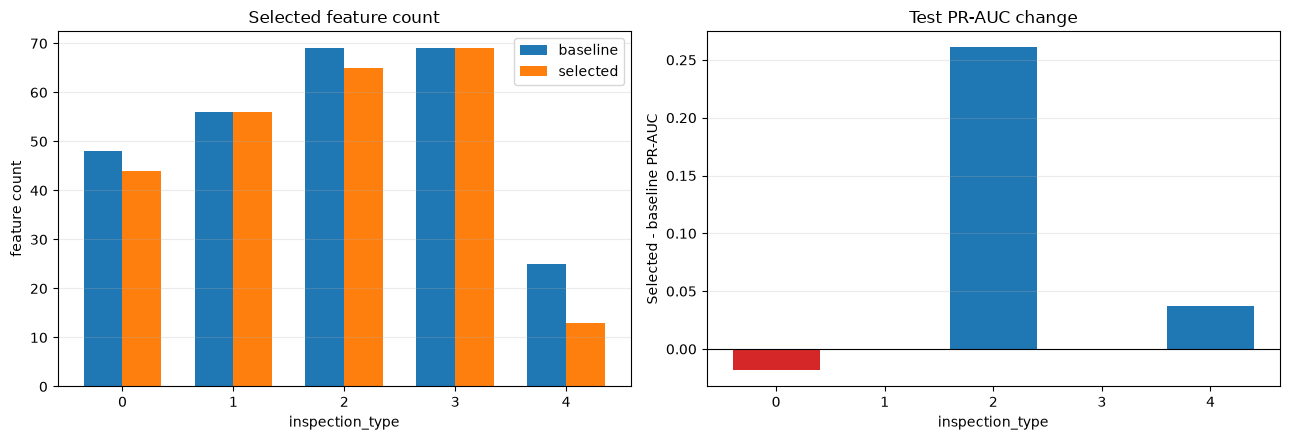

In [10]:
plot_df = test_delta_summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

positions = np.arange(len(plot_df))
width = 0.35
axes[0].bar(
    positions - width / 2,
    plot_df["baseline_features"],
    width,
    label="baseline",
)
axes[0].bar(
    positions + width / 2,
    plot_df["selected_features"],
    width,
    label="selected",
)
axes[0].set_xticks(positions, plot_df["inspection_type"])
axes[0].set_xlabel("inspection_type")
axes[0].set_ylabel("feature count")
axes[0].set_title("Selected feature count")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

colors = ["tab:blue" if value >= 0 else "tab:red" for value in plot_df["delta_pr_auc"]]
axes[1].bar(positions, plot_df["delta_pr_auc"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(positions, plot_df["inspection_type"])
axes[1].set_xlabel("inspection_type")
axes[1].set_ylabel("Selected - baseline PR-AUC")
axes[1].set_title("Test PR-AUC change")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 8. 사전 해석 기준과 주의사항

다음 조건을 모두 만족하면 보수적 feature selection 가설을 지지합니다.

- 전체 type 모델의 피처 수 합계를 25% 이상 감소
- Test에서 type별 허용 열화폭을 벗어나지 않은 유형이 4개 이상
- 보조 pooled PR-AUC 하락이 절대 0.01 이내

3개 type만 유지하면 부분 지지, 그 외는 지지하지 않는 것으로 판정합니다.

Permutation importance는 상관된 피처 사이에서 중요도를 나누거나 서로 대체 가능한 피처를 낮게 평가할 수 있습니다. 특히 Type 4는 Train inner window의 양성이 매우 적어 중요도 순위의 불확실성이 큽니다.

In [11]:
selected_feature_names = {
    inspection_type: candidate_features_by_type[inspection_type][
        validation_selection.loc[inspection_type, "selected_candidate"]
    ]
    for inspection_type in inspection_types
}

baseline_pooled = pooled_test_results.loc["baseline"]
selected_pooled = pooled_test_results.loc["selected"]
test_start = test_scope_df[TIME_COLUMN].min()
test_end = test_scope_df[TIME_COLUMN].max()

result_snapshot = {
    "judgement": experiment_judgement,
    "total_baseline_features": total_baseline_features,
    "total_selected_features": total_selected_features,
    "overall_feature_reduction": float(overall_feature_reduction),
    "nondegraded_types": nondegraded_types,
    "baseline_pooled_pr_auc": float(baseline_pooled["pr_auc"]),
    "selected_pooled_pr_auc": float(selected_pooled["pr_auc"]),
    "pooled_delta_pr_auc": float(pooled_delta_pr_auc),
    "selected_pooled_recall": float(selected_pooled["recall"]),
    "selected_pooled_tp": int(selected_pooled["tp"]),
    "selected_pooled_fn": int(selected_pooled["fn"]),
    "selected_pooled_false_call_reduction": float(
        selected_pooled["tn"] / (selected_pooled["tn"] + selected_pooled["fp"])
    ),
    "test_start": str(test_start),
    "test_end": str(test_end),
}

selection_lines = "\n".join(
    f"- Type {inspection_type}: {row['selected_candidate']}, "
    f"{int(row['baseline_features'])} → {int(row['selected_features'])}개 "
    f"({row['reduction_pct']:.1%} 감소), Test ΔPR-AUC "
    f"{test_delta_summary.loc[inspection_type, 'delta_pr_auc']:+.6f}"
    for inspection_type, row in validation_selection.iterrows()
)

conclusion = f'''
### 실행 결과 요약

{selection_lines}

- 전체 피처 수 합계: **{total_baseline_features} → {total_selected_features}개** ({overall_feature_reduction:.1%} 감소)
- 허용 열화폭 이내 Test type: **{nondegraded_types}/5**
- Pooled Test PR-AUC: **{baseline_pooled['pr_auc']:.6f} → {selected_pooled['pr_auc']:.6f}** ({pooled_delta_pr_auc:+.6f})
- Pooled Test Recall: **{baseline_pooled['recall']:.2%} → {selected_pooled['recall']:.2%}**
- 판정: **{experiment_judgement}**

주 결론은 type별 PR-AUC와 피처 감소율입니다. Pooled 확률은 type별 모델의 score scale 차이에 영향을 받을 수 있어 보조 지표로만 해석합니다. Test 확인 후 선택 규칙이나 피처 집합을 변경하지 않습니다.

비교 실험이므로 모델 파일을 저장하지 않습니다.
'''
display(Markdown(conclusion))
print("SELECTED_FEATURES", selected_feature_names)
print("RESULT_SNAPSHOT", result_snapshot)


### 실행 결과 요약

- Type 0: no_meta, 48 → 44개 (8.3% 감소), Test ΔPR-AUC -0.018467
- Type 1: all_features, 56 → 56개 (0.0% 감소), Test ΔPR-AUC +0.000000
- Type 2: no_meta, 69 → 65개 (5.8% 감소), Test ΔPR-AUC +0.260758
- Type 3: all_features, 69 → 69개 (0.0% 감소), Test ΔPR-AUC +0.000000
- Type 4: top_50_pct, 25 → 13개 (48.0% 감소), Test ΔPR-AUC +0.037283

- 전체 피처 수 합계: **267 → 247개** (7.5% 감소)
- 허용 열화폭 이내 Test type: **4/5**
- Pooled Test PR-AUC: **0.315411 → 0.339216** (+0.023805)
- Pooled Test Recall: **31.61% → 27.70%**
- 판정: **not_supported**

주 결론은 type별 PR-AUC와 피처 감소율입니다. Pooled 확률은 type별 모델의 score scale 차이에 영향을 받을 수 있어 보조 지표로만 해석합니다. Test 확인 후 선택 규칙이나 피처 집합을 변경하지 않습니다.

비교 실험이므로 모델 파일을 저장하지 않습니다.


SELECTED_FEATURES {0: ['inspection_feat1', 'inspection_feat2', 'inspection_feat3', 'inspection_feat4', 'inspection_feat5', 'inspection_feat6', 'inspection_feat7', 'inspection_feat8', 'inspection_feat9', 'inspection_feat10', 'inspection_feat11', 'inspection_feat12', 'inspection_feat16', 'inspection_feat17', 'inspection_feat18', 'inspection_feat19', 'inspection_feat20', 'inspection_feat22', 'inspection_feat23', 'inspection_feat24', 'inspection_feat25', 'inspection_feat26', 'inspection_feat27', 'inspection_feat28', 'inspection_feat29', 'inspection_feat30', 'inspection_feat31', 'inspection_feat40', 'inspection_feat41', 'inspection_feat42', 'inspection_feat43', 'inspection_feat44', 'inspection_feat45', 'inspection_feat46', 'inspection_feat47', 'inspection_feat48', 'inspection_feat49', 'inspection_feat53', 'inspection_feat54', 'inspection_feat55', 'inspection_feat56', 'inspection_feat57', 'inspection_feat58', 'inspection_feat59'], 1: ['meta_feat1', 'meta_feat2', 'meta_feat3', 'meta_feat4', '